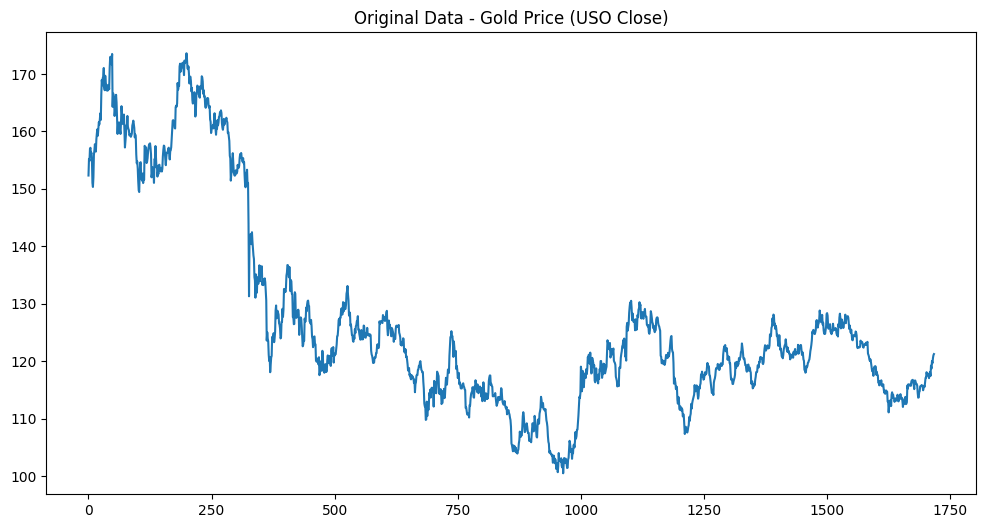

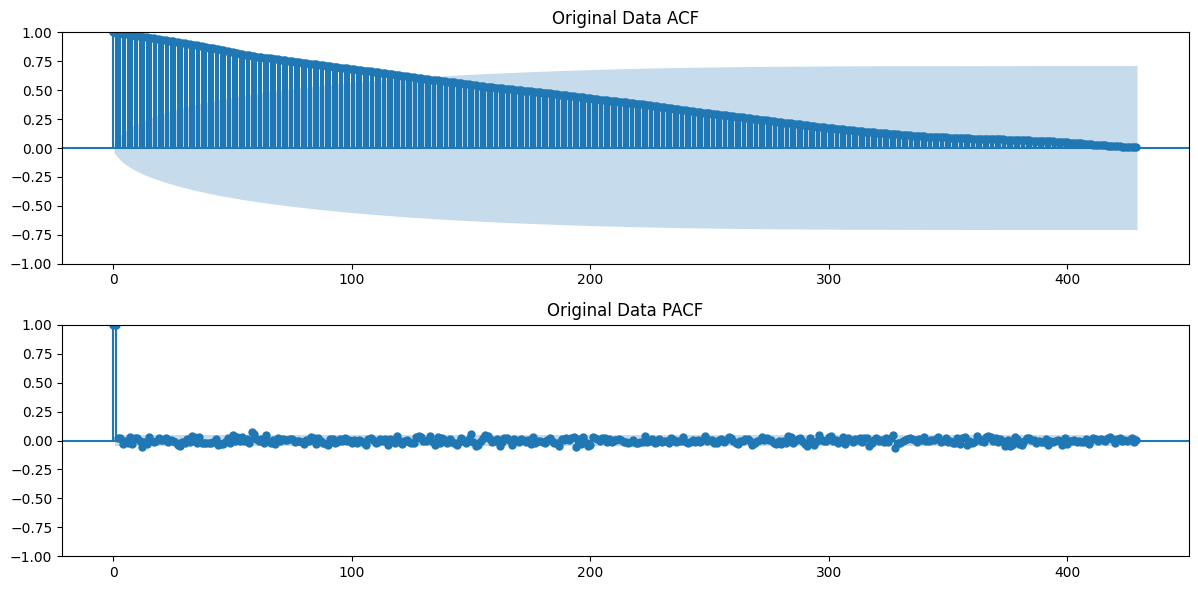

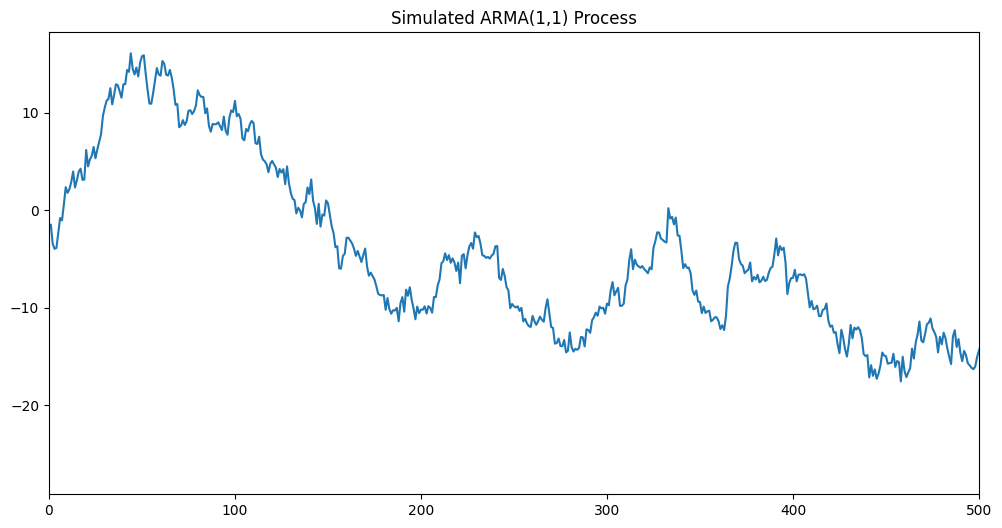

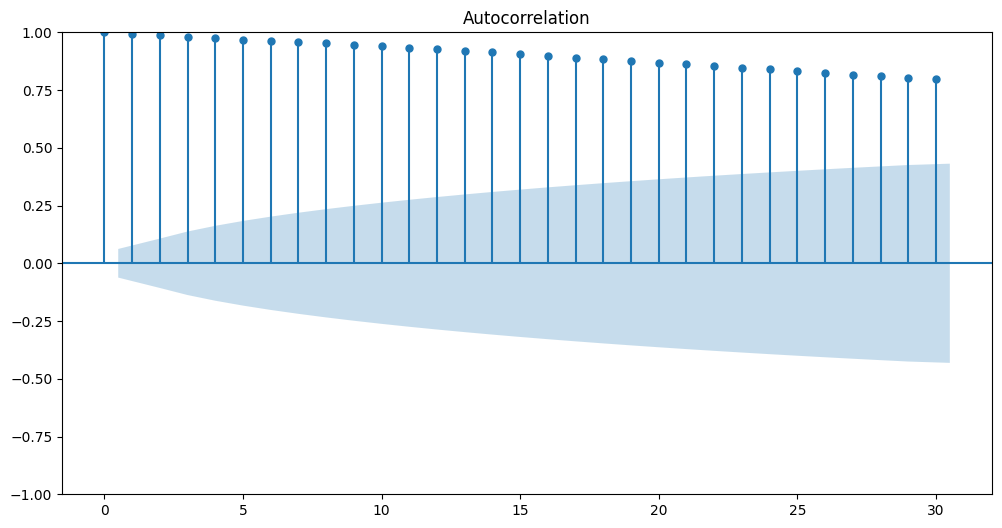

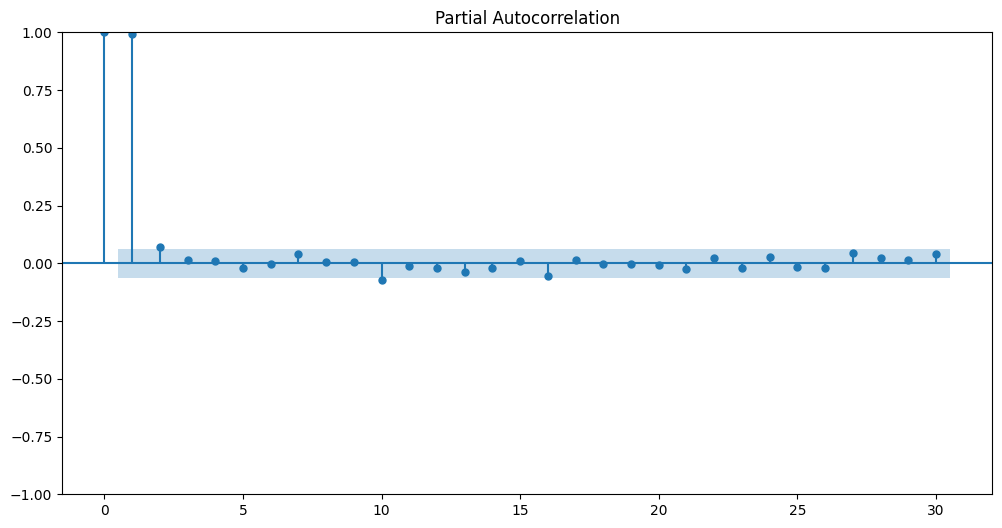

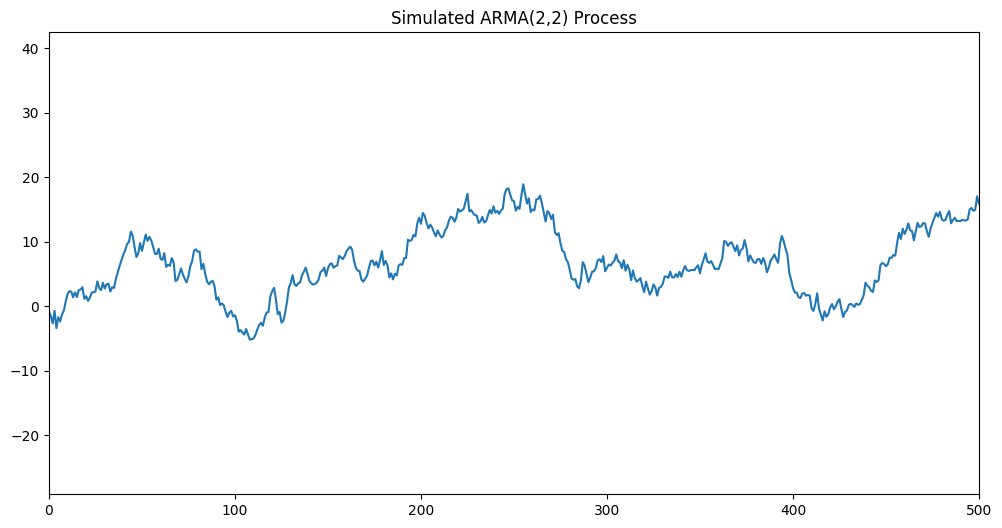

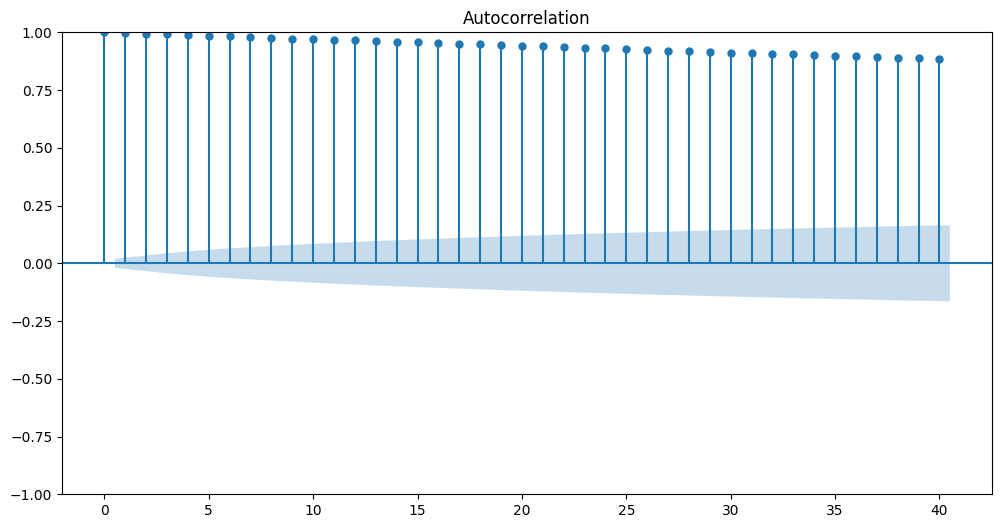

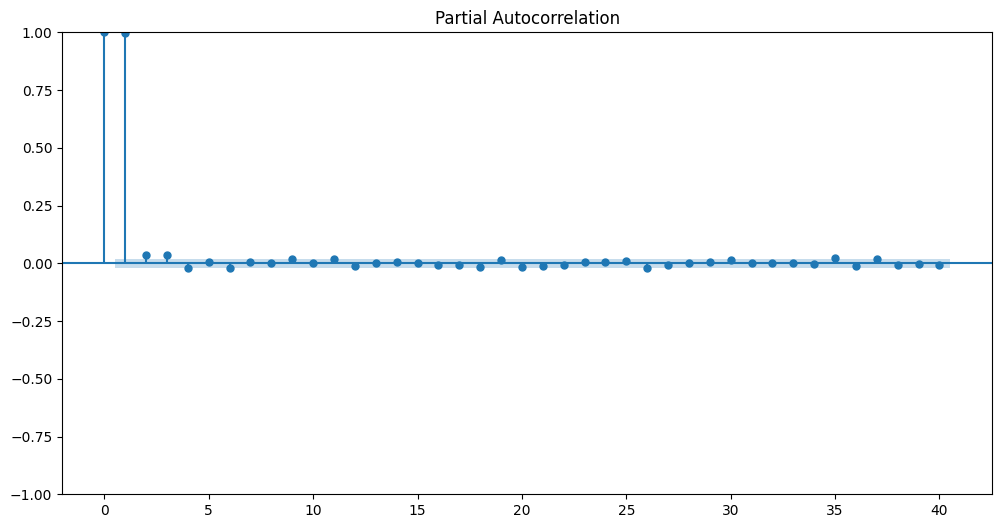

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
# Load dataset
data = pd.read_csv("FINAL_USO.csv")
data.head()
# Declare required variables and set figure size, and visualise the data
N = 1000
plt.rcParams["figure.figsize"] = [
    12,
    6,
]  # plt.rcParams is a dictionary-like object in Matplotlib
X = data["Close"]
plt.plot(X)
plt.title("Original Data - Gold Price (USO Close)")
plt.show()
plt.subplot(2, 1, 1)
plot_acf(X, lags=len(X) // 4, ax=plt.gca())
plt.title("Original Data ACF")
plt.subplot(2, 1, 2)
plot_pacf(X, lags=len(X) // 4, ax=plt.gca())
plt.title("Original Data PACF")
plt.tight_layout()
plt.show()
# Fitting the ARMA(1,1) model and deriving parameters
arma11_model = ARIMA(X, order=(1, 0, 1)).fit()
phi1_arma11 = arma11_model.params["ar.L1"]
theta1_arma11 = arma11_model.params["ma.L1"]
# Simulate ARMA(1,1) Process
ar1 = np.array([1, -phi1_arma11])
ma1 = np.array([1, theta1_arma11])
ARMA_1 = ArmaProcess(ar1, ma1).generate_sample(nsample=N)
plt.plot(ARMA_1)
plt.title("Simulated ARMA(1,1) Process")
plt.xlim([0, 500])
plt.show()
# Plot ACF and PACF for ARMA(1,1)
plot_acf(ARMA_1)
plt.show()
plot_pacf(ARMA_1)
plt.show()
# Fitting the ARMA(2,2) model and deriving parameters
arma22_model = ARIMA(X, order=(2, 0, 2)).fit()
phi1_arma22 = arma22_model.params["ar.L1"]
phi2_arma22 = arma22_model.params["ar.L2"]
theta1_arma22 = arma22_model.params["ma.L1"]
theta2_arma22 = arma22_model.params["ma.L2"]
# Simulate ARMA(2,2) Process
ar2 = np.array([1, -phi1_arma22, -phi2_arma22])
ma2 = np.array([1, theta1_arma22, theta2_arma22])
ARMA_2 = ArmaProcess(ar2, ma2).generate_sample(nsample=N * 10)
plt.plot(ARMA_2)
plt.title("Simulated ARMA(2,2) Process")
plt.xlim([0, 500])
plt.show()
# Plot ACF and PACF for ARMA(2,2)
plot_acf(ARMA_2)
plt.show()
plot_pacf(ARMA_2)
plt.show()